# Pipeline VLM Mamografía — Preprocesamiento
**Autor:** Luis Enrique Medrano Santana  
**Asesor:** Luis Vives Garnique  
**Institución:** Pontificia Universidad Católica del Perú (PUCP)  
**Título:** Modelo generativo multimodal de visión-lenguaje orientado al apoyo a la toma de decisiones clínicas en el diagnóstico de cáncer de mama

---

## Descripción

Este notebook implementa el pipeline completo de **preprocesamiento** sobre el dataset VinDr-Mammo.
Comprende desde la instalación de dependencias hasta el preprocesamiento de imágenes DICOM, el cual permite la evaluación comparativa zero-shot y los demás procesos.
## Estructura

| Sección | Descripción |
|---------|-------------|
| 0 | Instalación de dependencias |
| 1 | Imports globales y configuración de rutas |
| 2 | Validación de integridad del dataset |
| 3 | Preprocesamiento DICOM → merge 2×2 |
| 4 | Generación de reportes sintéticos de referencia |

## Formato del merge 2×2

```
┌──────────────┬──────────────┐
│  R_CC        │  L_CC        │
│ (mama dcha,  │ (mama izq,   │
│  vista CC)   │  vista CC)   │
├──────────────┼──────────────┤
│  R_MLO       │  L_MLO       │
│ (mama dcha,  │ (mama izq,   │
│  vista MLO)  │  vista MLO)  │
└──────────────┴──────────────┘
```

---
## Sección 0 — Instalación de dependencias

Instala todas las bibliotecas necesarias con versiones fijadas para garantizar reproducibilidad.

**Reiniciar el runtime después de ejecutar esta celda.**

In [1]:
# ── Instalación de dependencias con versiones fijadas ─────────────────────────

!pip install -q \
    "transformers>=5.4.0" \
    "accelerate>=0.26.0" \
    "bitsandbytes>=0.43.0" \
    "peft>=0.10.0" \
    "qwen-vl-utils>=0.0.8" \
    "bert-score" \
    "rouge-score" \
    "scikit-learn" \
    "scipy" \
    "pydicom" \
    "opencv-python-headless" \
    "Pillow>=10.0" \
    "tqdm" \
    "sentencepiece" \
    "protobuf"

print('Instalación completa. Reinicia el runtime antes de continuar.')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 14.9 MB/s eta 0:00:00
Instalación completa. Reinicia el runtime antes de continuar.


---
## Sección 1 — Imports globales y configuración

Centraliza todos los imports y variables de configuración.
Las secciones siguientes asumen que esta celda ya fue ejecutada.

**Rutas principales en Google Drive:**
- `images/` — DICOMs originales organizados por `study_id/`
- `processed_dcm/` — PNGs merge 2×2 tras preprocesamiento
- `metadata/` — CSVs de anotaciones VinDr-Mammo
- `results/` — JSONs con resultados de evaluación

In [ ]:
# ── Montar Google Drive ───────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Imports ──────────────────────────────────────────────────────────
import os
import gc
import re
import json
import time
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

import cv2
import pydicom
from PIL import Image
import torch
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# RUTAS — Modificable
# ─────────────────────────────────────────────────────────────────────────────
DRIVE_ROOT = '/content/drive/MyDrive/vindr_1000'
IMAGES_ROOT = f'{DRIVE_ROOT}/images'
PROCESSED_DIR = f'{DRIVE_ROOT}/processed_dcm'
META_DIR = f'{DRIVE_ROOT}/metadata'
RESULTS_DIR = f'{DRIVE_ROOT}/results'

# CSVs de VinDr-Mammo
META_CSV = f'{META_DIR}/selected_1000_studies.csv'
BREAST_CSV = f'{META_DIR}/breast-level_annotations.csv'
FINDING_CSV = f'{META_DIR}/finding_annotations.csv'
REPORTS_CSV = f'{META_DIR}/synthetic_reports_1000.csv'
VAL_CSV = f'{META_DIR}/validation_report.csv'

# Crear carpetas de salida si no existen
for d in [PROCESSED_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# CREDENCIALES
# HF_TOKEN: token de HuggingFace con acceso aprobado a google/medgemma-4b-it
# ─────────────────────────────────────────────────────────────────────────────
HF_TOKEN = '...'

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURACIÓN GLOBAL
# ─────────────────────────────────────────────────────────────────────────────
RANDOM_SEED = 20201531
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ── Verificación del entorno ──────────────────────────────────────────────────
print('Configuración global cargada')
print(f'   PyTorch : {torch.__version__}')
print(f'   CUDA : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Mounted at /content/drive
Configuración global cargada
   PyTorch : 2.10.0+cu128
   CUDA : True
   GPU : Tesla T4
   VRAM : 15.6 GB


In [3]:
# ── Cargar metadatos y crear DataFrames globales ──────────────────────────────
# Estos DataFrames se reutilizan en todas las secciones del pipeline.
# breast_df contiene una fila por vista (4 filas por estudio).
# meta_df contiene una fila por estudio con el BIRADS y densidad consolidados.

meta_df = pd.read_csv(META_CSV)
breast_df = pd.read_csv(BREAST_CSV)

# Normalizar nombre de columna BIRADS
if 'birads_max' in meta_df.columns:
    meta_df = meta_df.rename(columns={'birads_max': 'birads'})

# Normalizar a valores escalares: 'BI-RADS 2' → 2, 'DENSITY C' → 'C'
meta_df['birads_norm'] = meta_df['birads'].str.extract(r'(\d)').astype(int)
meta_df['density_norm'] = meta_df['density'].str.strip().str[-1]

# Separar splits
train_df = meta_df[meta_df['our_split'] == 'train'].reset_index(drop=True)
test_df = meta_df[meta_df['our_split'] == 'test'].reset_index(drop=True)

print(f'Total estudios: {len(meta_df)}')
print(f'Train: {len(train_df)}')
print(f'Test: {len(test_df)}')
print(f'\nDistribución BI-RADS:')
print(meta_df['birads_norm'].value_counts().sort_index())
print(f'\nDistribución densidad ACR:')
print(meta_df['density_norm'].value_counts().sort_index())

Total estudios: 1000
Train: 800
Test: 200

Distribución BI-RADS:
birads_norm
1    501
2    313
3     87
4     75
5     24
Name: count, dtype: int64

Distribución densidad ACR:
density_norm
A      7
B     99
C    757
D    137
Name: count, dtype: int64


---
## Sección 2 — Validación de integridad del dataset

Verifica que los estudios cumplen 5 condiciones antes de procesar:

1. El directorio del estudio existe en Drive
2. Los DICOMs son legibles (headers válidos)
3. Las 4 vistas requeridas están presentes: R_CC, L_CC, R_MLO, L_MLO
4. Las etiquetas BI-RADS (1-5) y densidad (A-D) son válidas
5. El PNG del merge ya existe y no está corrupto

**Output:** `validation_report.csv` con el estado de cada estudio.  
**Resiliencia:** si `validation_report.csv` ya existe, se omite la validación (`skip_if_exists=True`).

In [4]:
# ── Validación de integridad de los estudios ──────────────────────────────────
# Si validation_report.csv ya existe, se carga directamente.

SKIP_VALIDATION = Path(VAL_CSV).exists()

if SKIP_VALIDATION:
    print('Validación ya completada — cargando reporte existente')
    val_df = pd.read_csv(VAL_CSV)
else:
    # Vistas requeridas para construir el merge 2×2
    VALID_BIRADS = {1, 2, 3, 4, 5}
    VALID_DENSITY = {'A', 'B', 'C', 'D'}
    REQUIRED_VIEWS = {('L', 'CC'), ('R', 'CC'), ('L', 'MLO'), ('R', 'MLO')}

    results = []
    for _, row in tqdm(meta_df.iterrows(), total=len(meta_df), desc='Validando'):
        study_id = str(row['study_id'])
        study_dir = Path(IMAGES_ROOT) / study_id
        issues = []

        record = {
            'study_id': study_id, 'dir_exists': False,
            'n_readable': 0, 'n_corrupt': 0,
            'has_4_views': False, 'missing_views': '',
            'has_valid_birads': False, 'has_valid_density': False,
            'png_exists': False, 'png_valid': False,
            'status': 'UNKNOWN', 'issues': ''
        }

        # CHECK 1: Directorio del estudio existe
        if not study_dir.exists():
            record.update({'issues': 'DIR_MISSING', 'status': 'FAIL'})
            results.append(record)
            continue
        record['dir_exists'] = True

        # CHECK 2: DICOMs legibles — solo se leen headers para eficiencia
        dicom_files = list(study_dir.glob('*.dicom')) or list(study_dir.glob('*.dcm'))
        readable = corrupt = 0
        for dcm in dicom_files:
            try:
                ds = pydicom.dcmread(str(dcm), stop_before_pixels=True)
                readable += 1 if hasattr(ds, 'Rows') else 0
                corrupt += 0 if hasattr(ds, 'Rows') else 1
            except Exception:
                corrupt += 1
        record.update({'n_readable': readable, 'n_corrupt': corrupt})
        if readable == 0:
            issues.append('ALL_CORRUPT')

        # CHECK 3: Las 4 vistas presentes (R_CC, L_CC, R_MLO, L_MLO)
        study_rows    = breast_df[breast_df['study_id'] == study_id]
        present_views = set()
        for _, brow in study_rows.iterrows():
            lat = str(brow.get('laterality',    '')).strip().upper()
            view = str(brow.get('view_position', '')).strip().upper()
            img_id = str(brow.get('image_id', ''))
            dcm_path = study_dir / f'{img_id}.dicom'
            if not dcm_path.exists():
                dcm_path = study_dir / f'{img_id}.dcm'
            if lat and view and dcm_path.exists():
                present_views.add((lat, view))
        missing = REQUIRED_VIEWS - present_views
        record.update({'has_4_views': len(missing) == 0,
                       'missing_views': '|'.join(f'{l}_{v}' for l, v in missing)})
        if missing:
            issues.append(f'MISSING_VIEWS({len(missing)})')

        # CHECK 4: Etiquetas BIRADS y densidad válidas
        birads_match = re.search(r'\b([1-5])\b', str(row.get('birads', '')))
        density_match = re.search(r'\b([ABCD])\b', str(row.get('density', '')).upper())
        record['has_valid_birads']  = birads_match is not None
        record['has_valid_density'] = density_match is not None
        if not record['has_valid_birads']:  issues.append('INVALID_BIRADS')
        if not record['has_valid_density']: issues.append('INVALID_DENSITY')

        # CHECK 5: PNG merge 2×2 ya existe y es válido
        png_path = Path(PROCESSED_DIR) / f'{study_id}.png'
        record['png_exists'] = png_path.exists()
        if png_path.exists():
            try:
                img = Image.open(str(png_path))
                img.verify()
                record['png_valid'] = True
            except Exception:
                issues.append('PNG_CORRUPT')

        # Estado final: OK / WARN (usable con limitaciones) / FAIL
        record['issues'] = '|'.join(issues) if issues else 'OK'
        if not issues:
            record['status'] = 'OK'
        elif 'ALL_CORRUPT' in record['issues'] or 'DIR_MISSING' in record['issues']:
            record['status'] = 'FAIL'
        else:
            record['status'] = 'WARN' if (
                len(present_views) >= 2 and
                record['has_valid_birads'] and
                record['has_valid_density']
            ) else 'FAIL'

        results.append(record)

    val_df = pd.DataFrame(results)
    val_df.to_csv(VAL_CSV, index=False)
    print(f'Reporte guardado: {VAL_CSV}')

# Resumen de validación
counts = val_df['status'].value_counts()
print(f'\nResumen de validación:')
print(f'  OK      : {counts.get("OK",   0)}')
print(f'  WARN    : {counts.get("WARN", 0)}')
print(f'  FAIL    : {counts.get("FAIL", 0)}')
print(f'  Usables : {counts.get("OK",0) + counts.get("WARN",0)}')

Validación ya completada — cargando reporte existente

Resumen de validación:
  OK      : 997
  WARN    : 0
  FAIL    : 0
  Usables : 997


---
## Sección 3 — Preprocesamiento DICOM → merge 2×2

Convierte cada DICOM a PNG normalizado y construye la imagen compuesta 2×2.

### Pipeline por imagen DICOM:
1. **Lectura** del `pixel_array` con corrección de `RescaleSlope/Intercept`
2. **Inversión MONOCHROME1**: si la fotometría es `MONOCHROME1`, se invierte para que el tejido sea blanco
3. **Normalización min-max** a `uint8` [0, 255]
4. **Segmentación Otsu** + morfología → máscara de la mama → crop al bounding box + padding 2%
5. **CLAHE** (`clipLimit=2.0`, `tileGridSize=8×8`) — mejora contraste local sin saturar
6. **Resize** a 448×448 (`INTER_AREA`) — preserva calidad en reducción

### Layout del merge 2×2 (1024×1024 px sin borde entre cuadrantes):
```
┌──────────┬──────────┐
│  R_CC    │  L_CC    │   top-left  = mama DERECHA, vista CC
│          │          │   top-right = mama IZQUIERDA, vista CC
├──────────┼──────────┤
│  R_MLO   │  L_MLO   │   bot-left  = mama DERECHA, vista MLO
│          │          │   bot-right = mama IZQUIERDA, vista MLO
└──────────┴──────────┘
```

In [5]:
# ── Funciones de preprocesamiento ─────────────────────────────────────────────

TILE_SIZE = 448  # Tamaño de cada cuadrante en píxeles


def dicom_to_array(dicom_path: str) -> np.ndarray:
    """
    Lee un DICOM y retorna array uint8 preprocesado con el pipeline completo:
    corrección de slope/intercept → inversión MONOCHROME1 → normalización →
    segmentación Otsu → crop mama → CLAHE → resize 448×448.

    """
    # 1. Lectura y corrección de slope/intercept
    ds = pydicom.dcmread(dicom_path)
    img = ds.pixel_array.astype(np.float32)
    slope = float(getattr(ds, 'RescaleSlope', 1))
    intercept = float(getattr(ds, 'RescaleIntercept', 0))
    img = img * slope + intercept

    # 2. Normalización min-max a uint8
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    img = (img * 255).astype(np.uint8)

    # 3. Inversión MONOCHROME1
    # En MONOCHROME1 el fondo es blanco y el tejido oscuro — se invierte
    pi = str(getattr(ds, 'PhotometricInterpretation', '')).upper()
    if 'MONOCHROME1' in pi:
        img = 255 - img

    # 4. Segmentación Otsu + morfología → máscara de mama → crop + padding
    blurred = cv2.GaussianBlur(img, (5, 5), 0)
    _, mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=4)

    # Encontrar el componente conectado más grande
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if n_labels > 1:
        # Ignorar el fondo (label 0), tomar la componente de mayor área
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        x, y = stats[largest, cv2.CC_STAT_LEFT], stats[largest, cv2.CC_STAT_TOP]
        w, h = stats[largest, cv2.CC_STAT_WIDTH], stats[largest, cv2.CC_STAT_HEIGHT]

        # Padding del 2% de cada dimensión
        pad_x = int(w * 0.02)
        pad_y = int(h * 0.02)
        x1 = max(0, x - pad_x)
        y1 = max(0, y - pad_y)
        x2 = min(img.shape[1], x + w + pad_x)
        y2 = min(img.shape[0], y + h + pad_y)
        img = img[y1:y2, x1:x2]

    # 5. CLAHE — mejora de contraste local adaptativo
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    # 6. Resize a TILE_SIZE×TILE_SIZE con INTER_AREA (mejor para reducción)
    img = cv2.resize(img, (TILE_SIZE, TILE_SIZE), interpolation=cv2.INTER_AREA)

    return img


def build_merge_2x2(study_id: str, breast_df: pd.DataFrame) -> Image.Image | None:
    """
    Construye la imagen compuesta 2×2 a partir de los 4 DICOMs de un estudio.
    Layout fijo:
        top-left  = R_CC  (mama derecha, vista cranio-caudal)
        top-right = L_CC  (mama izquierda, vista cranio-caudal)
        bot-left  = R_MLO (mama derecha, vista medio-lateral oblicua)
        bot-right = L_MLO (mama izquierda, vista medio-lateral oblicua)
    """
    study_dir = Path(IMAGES_ROOT) / study_id
    rows = breast_df[breast_df['study_id'] == study_id]

    # Mapa vista → posición en el canvas (fila, columna)
    slot_map = {
        ('R', 'CC'): (0, 0),   # top-left
        ('L', 'CC'): (0, 1),   # top-right
        ('R', 'MLO'): (1, 0),   # bot-left
        ('L', 'MLO'): (1, 1),   # bot-right
    }

    canvas = np.zeros((TILE_SIZE * 2, TILE_SIZE * 2), dtype=np.uint8)
    found = 0

    for _, row in rows.iterrows():
        lat = str(row.get('laterality', '')).strip().upper()
        view = str(row.get('view_position', '')).strip().upper()
        slot = slot_map.get((lat, view))
        if slot is None:
            continue

        # Buscar el DICOM del image_id correspondiente
        img_id = str(row.get('image_id', ''))
        dcm_path = study_dir / f'{img_id}.dicom'
        if not dcm_path.exists():
            dcm_path = study_dir / f'{img_id}.dcm'
        if not dcm_path.exists():
            continue

        try:
            tile = dicom_to_array(str(dcm_path))
            r, c = slot
            canvas[r*TILE_SIZE:(r+1)*TILE_SIZE, c*TILE_SIZE:(c+1)*TILE_SIZE] = tile
            found += 1
        except Exception as e:
            print(f' {study_id}/{dcm_path.name}: {e}')

    return Image.fromarray(canvas).convert('RGB') if found >= 2 else None

print('Funciones de preprocesamiento definidas.')
print(f' Tamaño de cada cuadrante : {TILE_SIZE}×{TILE_SIZE} px')
print(f' Tamaño del merge final : {TILE_SIZE*2}×{TILE_SIZE*2} px')

Funciones de preprocesamiento definidas.
 Tamaño de cada cuadrante : 448×448 px
 Tamaño del merge final : 896×896 px


In [6]:
# ── Ejecutar preprocesamiento sobre todos los estudios ────────────────────────
ok = skip = fail = 0

for _, row in tqdm(meta_df.iterrows(), total=len(meta_df), desc='Preprocesando'):
    study_id = str(row['study_id'])
    out_path = Path(PROCESSED_DIR) / f'{study_id}.png'

    # Si el PNG ya existe, saltar sin reprocesar
    if out_path.exists():
        skip += 1
        continue

    merged = build_merge_2x2(study_id, breast_df)
    if merged is None:
        fail += 1
    else:
        merged.save(str(out_path))
        ok += 1

total_pngs = len(list(Path(PROCESSED_DIR).glob('*.png')))
print(f'\nPreprocesamiento completo:')
print(f' Nuevos procesados: {ok}')
print(f' Ya existían: {skip}')
print(f' Fallidos: {fail}')
print(f' Total PNGs en Drive: {total_pngs}')

Preprocesando:   0%|          | 0/1000 [00:00<?, ?it/s]


Preprocesamiento completo:
 Nuevos procesados: 0
 Ya existían: 1000
 Fallidos: 0
 Total PNGs en Drive: 3883


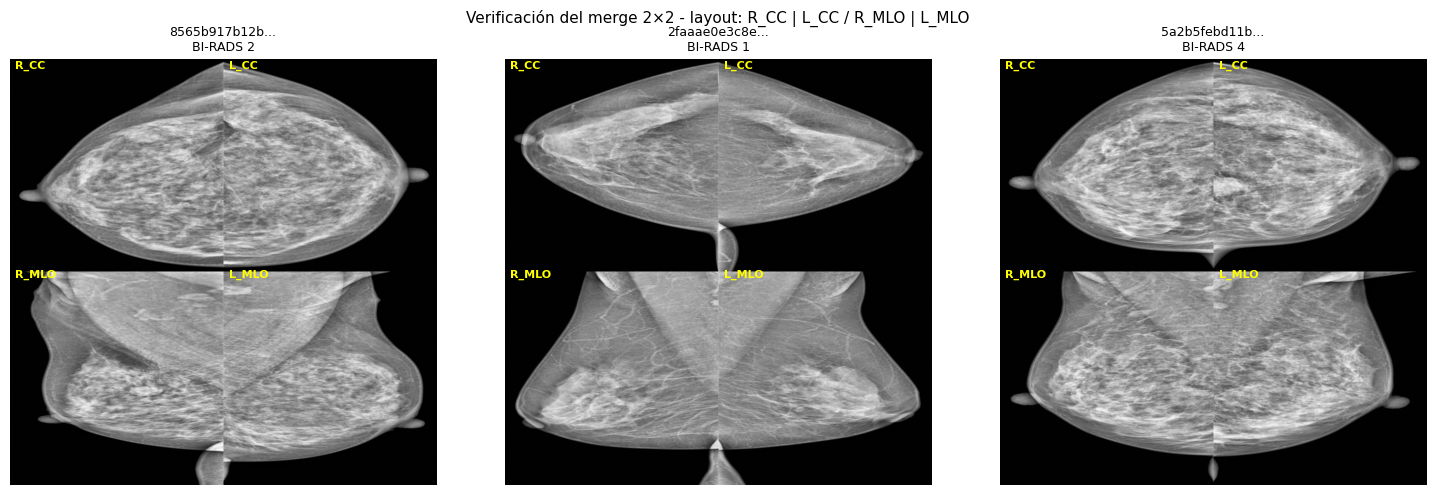

In [7]:
# ── Verificación visual del preprocesamiento ──────────────────────────────────
# Muestra 3 merges aleatorios para confirmar que el pipeline es correcto.
# El layout esperado: R_CC (top-left), L_CC (top-right), R_MLO (bot-left), L_MLO (bot-right)

import matplotlib.pyplot as plt
sample_ids = meta_df['study_id'].sample(3, random_state=RANDOM_SEED).tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, sid in zip(axes, sample_ids):
    png_path = Path(PROCESSED_DIR) / f'{sid}.png'
    if png_path.exists():
        img = Image.open(str(png_path))
        ax.imshow(img, cmap='gray')
        birads = meta_df[meta_df['study_id'] == sid]['birads_norm'].iloc[0]
        ax.set_title(f'{sid[:12]}...\nBI-RADS {birads}', fontsize=9)
        ax.axis('off')
        # Anotaciones de layout
        ax.text(10, 20, 'R_CC', color='yellow', fontsize=8, fontweight='bold')
        ax.text(460, 20, 'L_CC', color='yellow', fontsize=8, fontweight='bold')
        ax.text(10, 460, 'R_MLO', color='yellow', fontsize=8, fontweight='bold')
        ax.text(460, 460, 'L_MLO', color='yellow', fontsize=8, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'PNG no encontrado', ha='center', va='center')
        ax.axis('off')

plt.suptitle('Verificación del merge 2×2 - layout: R_CC | L_CC / R_MLO | L_MLO', fontsize=11)
plt.tight_layout()
plt.show()

---
## Sección 4 — Generación de reportes sintéticos de referencia

VinDr-Mammo no incluye reportes narrativos reales de radiólogos, solo etiquetas estructuradas
(BI-RADS, densidad, tipo de hallazgo). Esta sección construye reportes narrativos sintéticos
a partir de esas etiquetas, siguiendo el formato clínico estándar.

Los reportes sintéticos se usan como referencia para las métricas BERTScore y ROUGE-L.
Esta limitación se documenta explícitamente en los comentarios de `compute_metrics`.

**Formato del reporte sintético:**
```
INDICATION: Screening mammography.
COMPOSITION: The breasts are <densidad>.
FINDINGS: The <lado> breast demonstrates <hallazgo>. Assessment: <BI-RADS>.
IMPRESSION: Overall BI-RADS assessment: <X>. <recomendación clínica>.
```

In [8]:
# ── Construcción de reportes sintéticos ───────────────────────────────────────

# Mapeo densidad ACR → descripción clínica
DENSITY_MAP = {
    'DENSITY A': 'almost entirely fatty',
    'DENSITY B': 'scattered areas of fibroglandular density',
    'DENSITY C': 'heterogeneously dense',
    'DENSITY D': 'extremely dense',
}

# Recomendación clínica estándar por categoría BI-RADS
BIRADS_RECOMMENDATION = {
    1: 'Continue annual screening.',
    2: 'Continue annual screening.',
    3: 'Short-interval follow-up in 6 months recommended.',
    4: 'Biopsy should be considered.',
    5: 'Biopsy is highly recommended.',
}


def build_synthetic_report(study_id: str,
                            breast_df: pd.DataFrame,
                            finding_df: pd.DataFrame) -> str | None:
    """
    Construye un reporte narrativo estructurado a partir de las anotaciones de VinDr-Mammo.
    """
    rows = breast_df[breast_df['study_id'] == study_id]
    if rows.empty:
        return None

    # COMPOSITION - densidad por mama
    densities = rows.groupby('laterality')['breast_density'].first().to_dict()
    dens_L = DENSITY_MAP.get(densities.get('L', ''), 'unknown density')
    dens_R = DENSITY_MAP.get(densities.get('R', ''), 'unknown density')
    comp = (f'The breasts are {dens_L}.' if dens_L == dens_R
            else f'The left breast is {dens_L}. The right breast is {dens_R}.')

    # FINDINGS - por lateralidad, con BIRADS y hallazgos específicos
    findings_parts = []
    global_birads = 1   # BIRADS global = máximo entre ambas mamas

    for lat in ['L', 'R']:
        side = 'left' if lat == 'L' else 'right'
        lat_rows = rows[rows['laterality'] == lat]
        if lat_rows.empty:
            continue

        birads_str = lat_rows['breast_birads'].iloc[0]
        birads_match = re.search(r'(\d)', str(birads_str))
        birads_val = int(birads_match.group(1)) if birads_match else 1
        global_birads = max(global_birads, birads_val)

        # Para BIRADS 1-2 sin hallazgos significativos
        finds = finding_df[
            (finding_df['study_id'] == study_id) &
            (finding_df['laterality'] == lat)
        ]
        if finds.empty or birads_val <= 2:
            findings_parts.append(
                f'The {side} breast demonstrates no significant findings. '
                f'Assessment: {birads_str}.'
            )
        else:
            # Para BIRADS 3-5 incluir categoría del hallazgo
            cats = finds['finding_categories'].iloc[0]
            try:
                cats_list = eval(cats) if isinstance(cats, str) else [str(cats)]
                cats_str  = ', '.join(cats_list).lower()
            except Exception:
                cats_str = str(cats).lower()
            findings_parts.append(
                f'The {side} breast demonstrates {cats_str}. '
                f'Assessment: {birads_str}.'
            )

    if not findings_parts:
        return None

    # IMPRESSION - BI-RADS global con recomendación
    rec = BIRADS_RECOMMENDATION.get(global_birads, 'Clinical correlation recommended.')
    impression = f'Overall BI-RADS assessment: {global_birads}. {rec}'

    return (
        f'INDICATION: Screening mammography.\n'
        f'COMPOSITION: {comp}\n'
        f'FINDINGS: {" ".join(findings_parts)}\n'
        f'IMPRESSION: {impression}'
    )

print('Función de generación de reportes definida.')

Función de generación de reportes definida.


In [9]:
# ── Generar y guardar reportes sintéticos ─────────────────────────────────────
# Si el CSV ya existe, se carga directamente para evitar regenerar.

if Path(REPORTS_CSV).exists():
    print('Reportes ya generados - cargando desde Drive')
    reports_df = pd.read_csv(REPORTS_CSV)
else:
    finding_df = pd.read_csv(FINDING_CSV)

    records = []
    failed  = 0
    for _, row in tqdm(meta_df.iterrows(), total=len(meta_df), desc='Generando reportes'):
        sid = str(row['study_id'])
        report = build_synthetic_report(sid, breast_df, finding_df)
        if report:
            records.append({
                'study_id': sid,
                'full_report': report,
                'birads': row['birads'],
                'density': row['density'],
            })
        else:
            failed += 1

    reports_df = pd.DataFrame(records)
    reports_df.to_csv(REPORTS_CSV, index=False)
    print(f'Generados: {len(reports_df)} | Fallidos: {failed}')
    print(f'Guardado en: {REPORTS_CSV}')

print(f'\nTotal reportes: {len(reports_df)}')
print(f'\nEjemplo de reporte sintético:')
print('-' * 60)
print(reports_df['full_report'].iloc[0])

Reportes ya generados - cargando desde Drive

Total reportes: 997

Ejemplo de reporte sintético:
------------------------------------------------------------
INDICATION: Screening mammography.
COMPOSITION: The breasts are heterogeneously dense.
FINDINGS: The left breast demonstrates no significant findings. Assessment: BI-RADS 1. The right breast demonstrates no significant findings. Assessment: BI-RADS 2.
IMPRESSION: Overall assessment: BI-RADS 2.
